In [56]:
import sys
import pandas as pd
import numpy as np

sys.path.append('../../evaluation_utils/')
from evaluation import evaluation_func as fp_eval

from collections import OrderedDict

In [57]:
color_dict = OrderedDict()

color_dict["Methods"] = OrderedDict({
    "FedProt":"black",
    "Fisher":"#D44400",
    "Stouffer":"#E69F00",
    "REM":"#2E5EAA",
    "RankProd":"#009E73"
})

# Read results

In [58]:
dfs = {}

workdir = "/home/yuliya/repos/cosybio/FedProt/evaluation/bacterial/balanced/results" 
df = fp_eval.read_results(workdir,
                          deqms_name="/central_res.tsv",
                          fedprot_name="/DPE.csv")
dfs["Bacterial dataset"] = df
print(f"Proteins: {len(df)}")


workdir = "/home/yuliya/repos/cosybio/FedProt/evaluation/TMT_data/01_smaller_lib_balanced_PG_MajorPG/results" 
df = fp_eval.read_results(workdir,
                          deqms_name="/central_res.tsv",
                          fedprot_name="/DPE.csv")
dfs["Human serum dataset"] = df
print(f"Proteins: {len(df)}")

Results loaded for DEqMS with 2863 proteins.
Results loaded for FedProt with 2863 proteins.


Results loaded for Fisher with 2824 proteins.
Results loaded for REM with 3026 proteins.
Results loaded for Stouffer with 2238 proteins.
Results loaded for RankProd with 3026 proteins.
Results loaded from /home/yuliya/repos/cosybio/FedProt/evaluation/bacterial/balanced/results with 2238 genes. Adj.p-values were not log-transformed.
Results loaded for DEqMS with 532 proteins.
Results loaded for FedProt with 532 proteins.
Results loaded for Fisher with 432 proteins.
Results loaded for REM with 591 proteins.
Results loaded for Stouffer with 350 proteins.
Results loaded for RankProd with 591 proteins.
Results loaded from /home/yuliya/repos/cosybio/FedProt/evaluation/TMT_data/01_smaller_lib_balanced_PG_MajorPG/results with 350 genes. Adj.p-values were not log-transformed.


Proteins: 2238
Proteins: 350


In [59]:
log_dfs = {}
for k in dfs:
    df = dfs[k]
    df = df.replace(0,1e-300)
    for m in ["DEqMS", "FedProt", "Fisher","Stouffer","REM","RankProd"]:
        df.loc[df["pv_"+m] < 1e-300, "pv_"+m] = 1e-300
        df.loc[:, "pv_"+m] = -np.log10(df["pv_"+m])
    log_dfs[k] = df

# Cut-off selection

In [60]:
frac_DEP = {}
num_DEP = {}
p_values_cutoffs = [0.001, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
logFC_cutoffs = [0.15, 0.25, 0.35, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75]

for k in dfs:
    # create a df where rownames are lofFC cutoffs and colnames are p-value cutoffs
    frac_DEP[k] = pd.DataFrame(index=logFC_cutoffs, columns=p_values_cutoffs)
    num_DEP[k] = pd.DataFrame(index=logFC_cutoffs, columns=p_values_cutoffs)
    df = log_dfs[k]

    # for each logFC cutoff and p-value cutoff calculate the fraction of DEPs
    for logFC in logFC_cutoffs:
        for p_value in p_values_cutoffs:
            df_DEP = df[(df["lfc_DEqMS"] > logFC) & (df["pv_DEqMS"] > -np.log10(p_value))]
            num_DEP[k].loc[logFC, p_value] = len(df_DEP)
            frac_DEP[k].loc[logFC, p_value] = len(df_DEP) * 100 /len(df)


Bacterial dataset


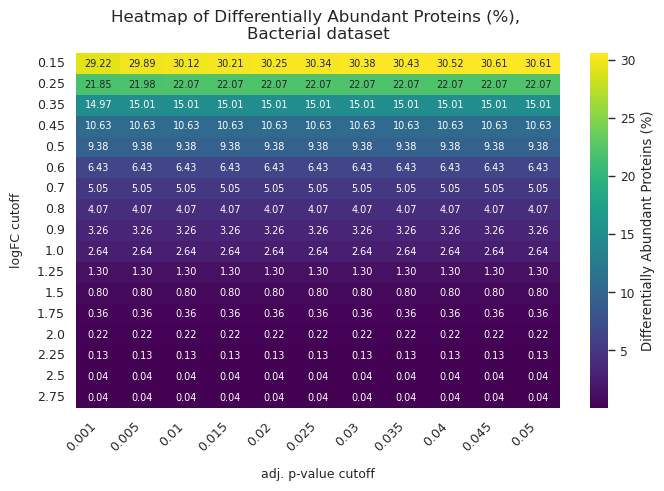

Human serum dataset


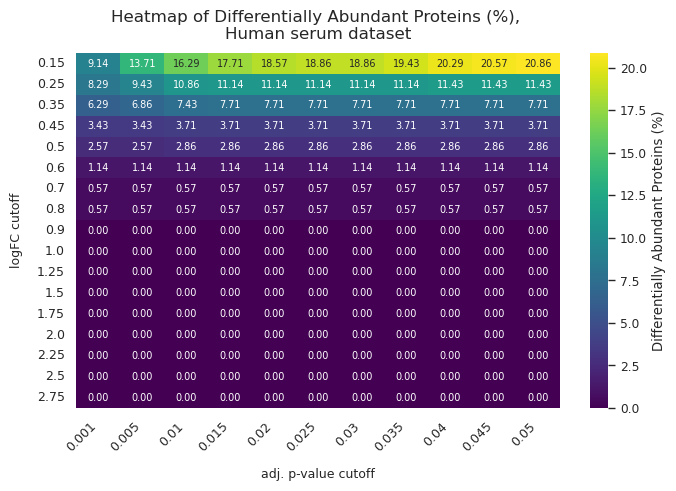

In [61]:
import seaborn as sns

sns.set_theme(context='paper', style='white')

for k in dfs:
    print(k)
    df_to_plot = frac_DEP[k].astype(float)
    fp_eval.dep_frac_heatmap(df_to_plot, f"Heatmap of Differentially Abundant Proteins (%), \n{k}")



# Jaccard calcualtion

In [62]:
fp_cutoffs = {}
fn_cutoffs = {}
jaccard_cutoffs = {}

for k in dfs:
    df = log_dfs[k]
    fp_cutoffs[k] = {}
    fn_cutoffs[k] = {}
    jaccard_cutoffs[k] = {}

    for m in ["FedProt", "Fisher", "Stouffer", "REM", "RankProd"]:
        fp_cutoffs[k][m] = pd.DataFrame(index=logFC_cutoffs, columns=p_values_cutoffs)
        fn_cutoffs[k][m] = pd.DataFrame(index=logFC_cutoffs, columns=p_values_cutoffs)
        jaccard_cutoffs[k][m] = pd.DataFrame(index=logFC_cutoffs, columns=p_values_cutoffs)

    for logFC in logFC_cutoffs:
        for p_value in p_values_cutoffs:
            fp_fn_b = fp_eval.calc_stats(
                df, 
                lfc_thr=logFC, adj_pval_thr=p_value,
                stats=["FP", "FN", "Jaccard"],
                methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
                column_name="pv_",
                top_genes=-1
            )
            for m in ["FedProt", "Fisher", "Stouffer", "REM", "RankProd"]:
                if num_DEP[k].loc[logFC, p_value] < 1:
                    fp_cutoffs[k][m].loc[logFC, p_value] = np.nan
                    jaccard_cutoffs[k][m].loc[logFC, p_value] = np.nan
                    fn_cutoffs[k][m].loc[logFC, p_value] = np.nan
                else:
                    fp_cutoffs[k][m].loc[logFC, p_value] = fp_fn_b.loc[m, "FP"]
                    jaccard_cutoffs[k][m].loc[logFC, p_value] = fp_fn_b.loc[m, "Jaccard"]
                    fn_cutoffs[k][m].loc[logFC, p_value] = fp_fn_b.loc[m, "FN"]
                
                

In [63]:
for k in dfs:
    # if the row is all nan, drop it
    for m in ["FedProt", "Fisher", "Stouffer", "REM", "RankProd"]:
        fp_cutoffs[k][m] = fp_cutoffs[k][m].dropna(axis=0, how='all')
        fn_cutoffs[k][m] = fn_cutoffs[k][m].dropna(axis=0, how='all')
        jaccard_cutoffs[k][m] = jaccard_cutoffs[k][m].dropna(axis=0, how='all')

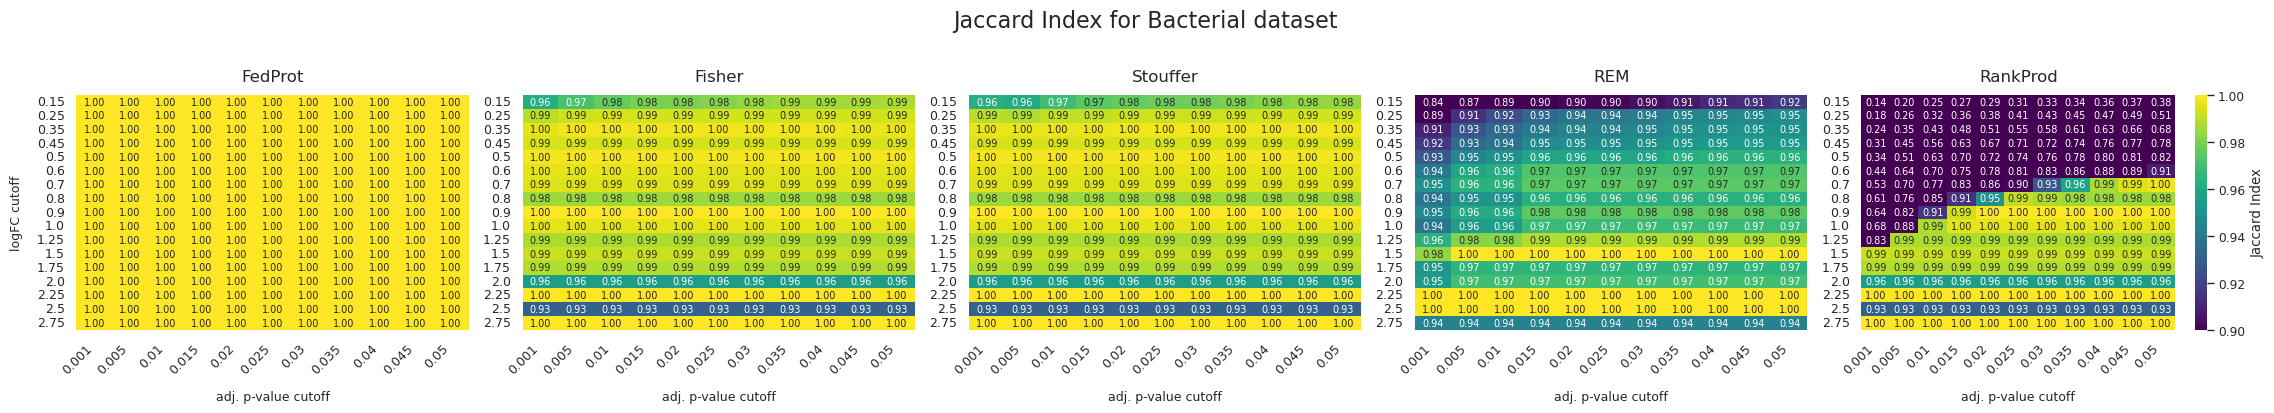

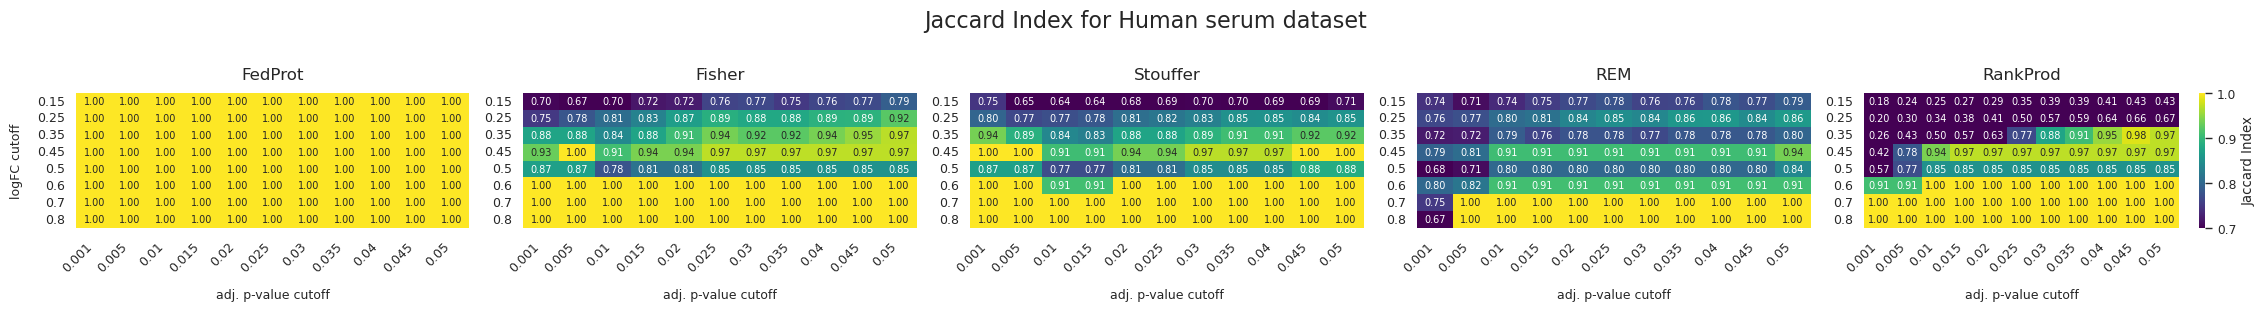

In [64]:
base_path = "/home/yuliya/repos/cosybio/FedProt/evaluation/aggregated_eval/figures/"

for k in dfs:
    # Plot grid for Jaccard Index
    fp_eval.plot_metric_grid(
        jaccard_cutoffs, dataset_key=k, metric_name="Jaccard Index",
        figsize=(23, 4) if k == "Bacterial dataset" else (23, 3),
        path_to_save=f"{base_path}{k}_jaccard.png",
        nrows=1, ncols=5
    )

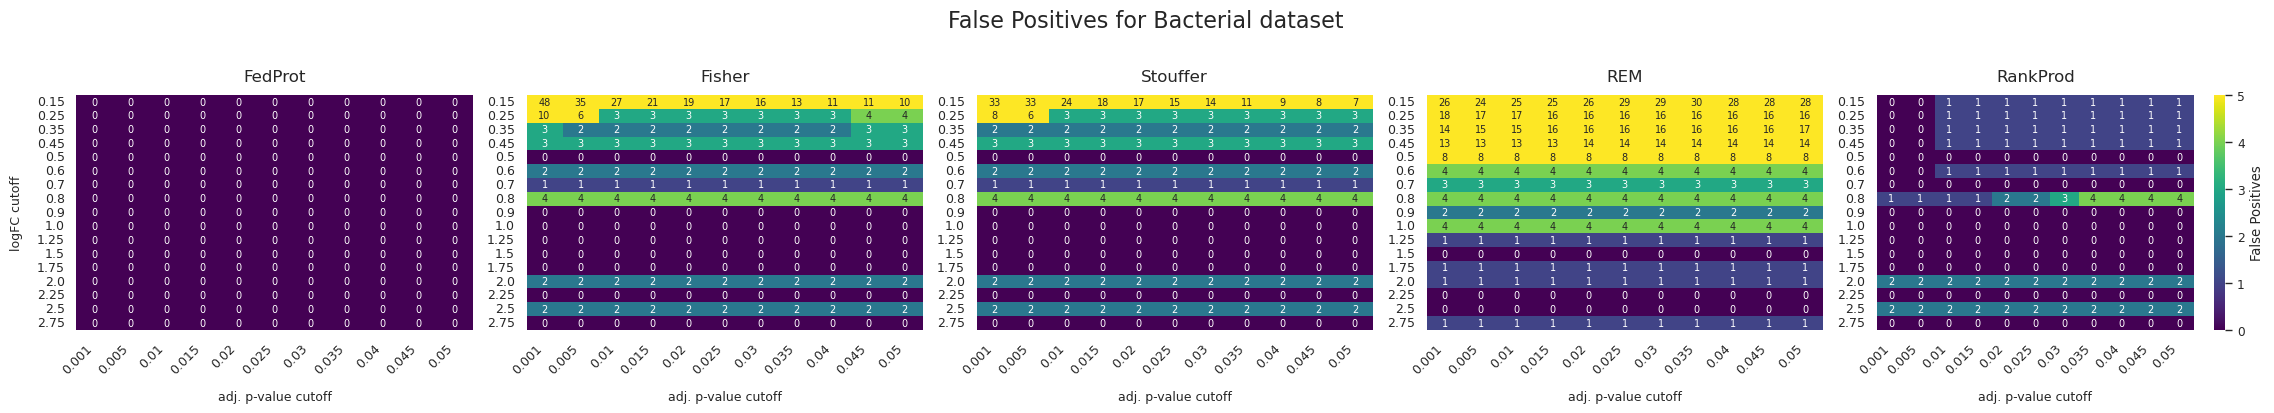

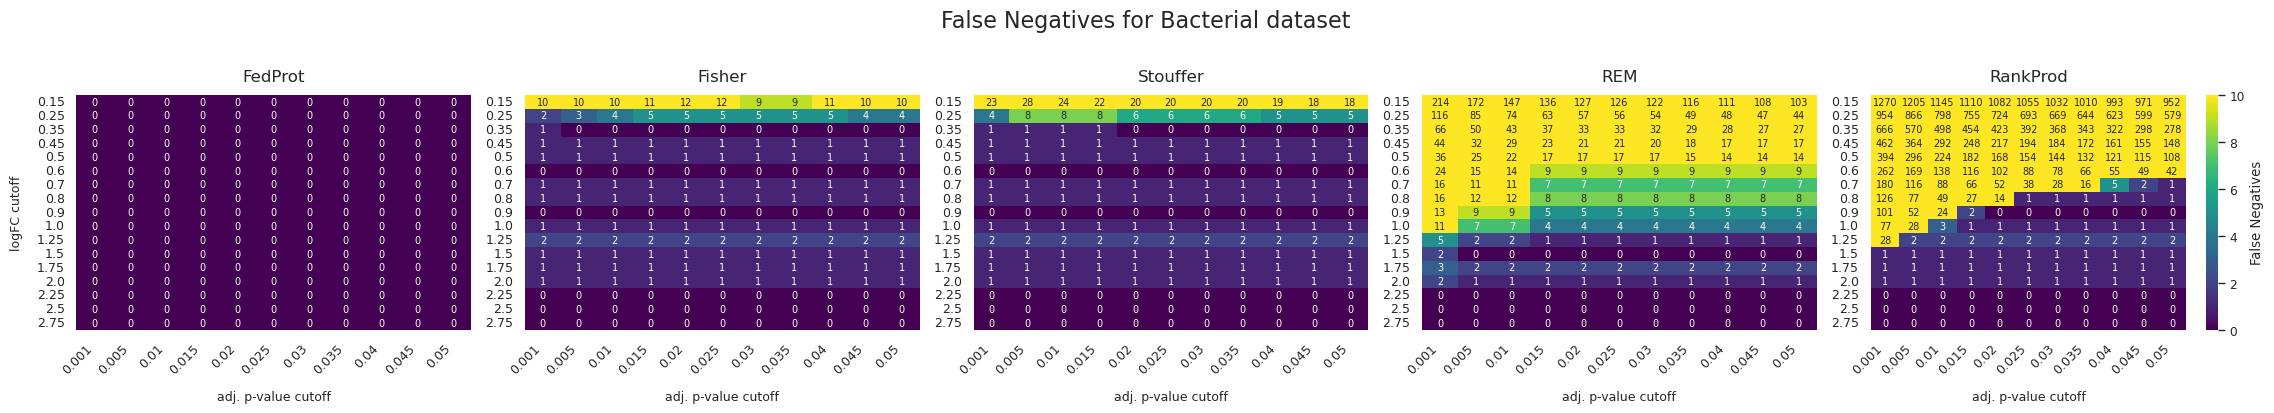

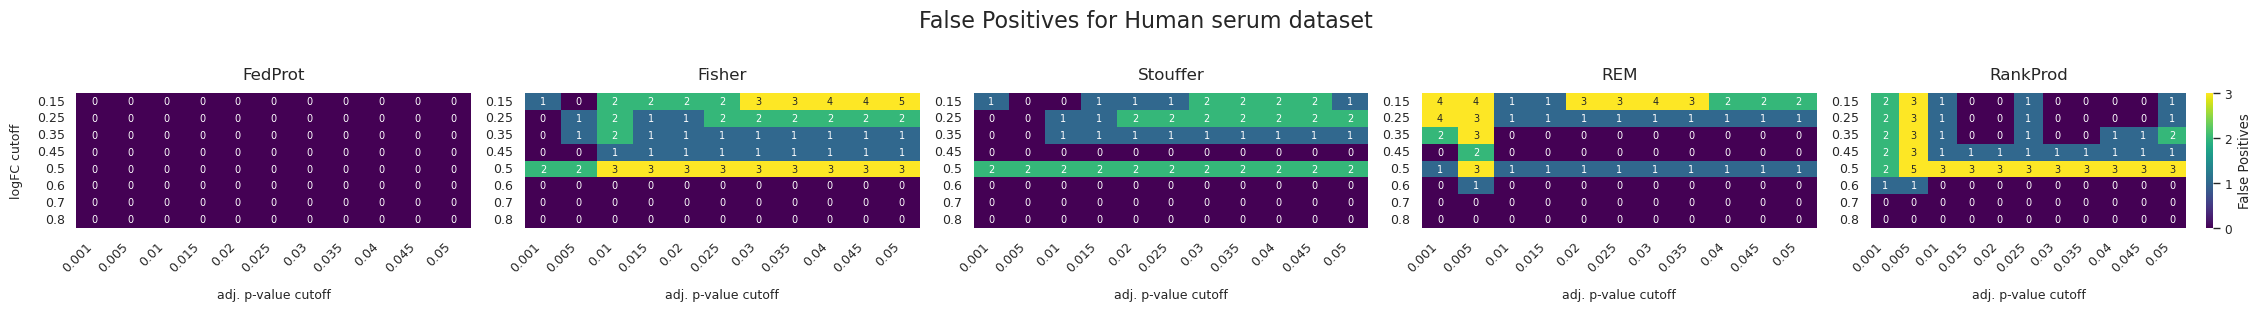

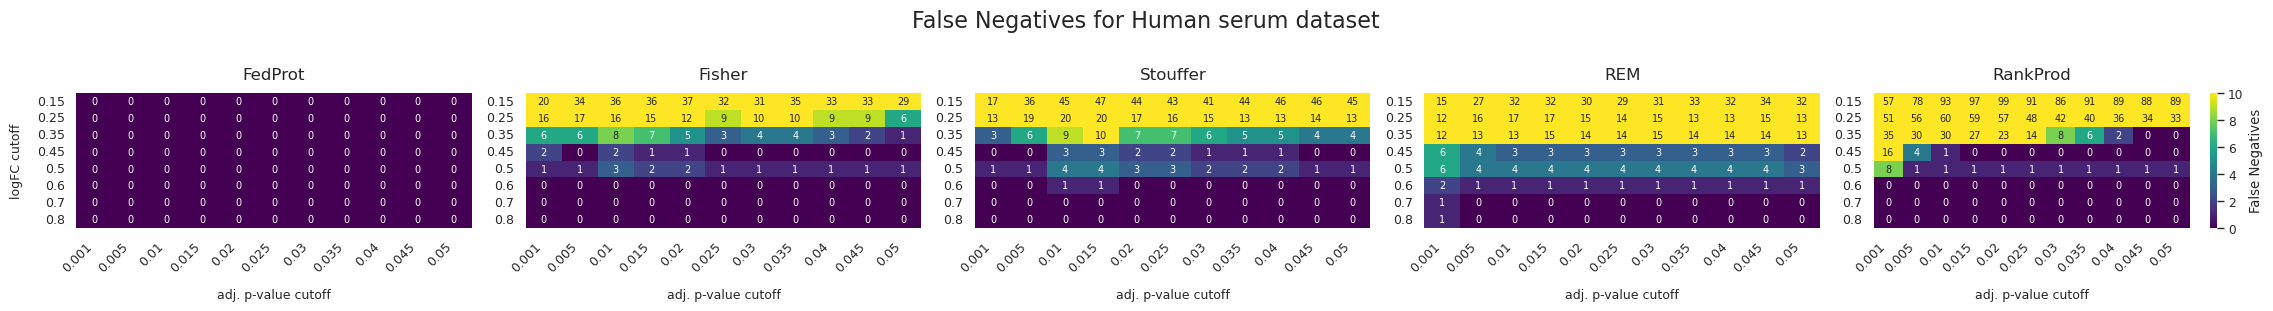

In [69]:
base_path = "/home/yuliya/repos/cosybio/FedProt/evaluation/aggregated_eval/figures/"

for k in dfs:
    # Plot grid for False Positives
    fp_eval.plot_metric_grid(
        fp_cutoffs, dataset_key=k, metric_name="False Positives",
        global_max_value=5 if k == "Bacterial dataset" else 3,
        figsize=(23, 4) if k == "Bacterial dataset" else (23, 3),
        path_to_save=f"{base_path}{k}_fp.png",
        nrows=1, ncols=5
    )
    # Plot grid for False Negatives
    fp_eval.plot_metric_grid(
        fn_cutoffs, dataset_key=k, metric_name="False Negatives",
        global_max_value=10,
        figsize=(23, 4) if k == "Bacterial dataset" else (23, 3),
        path_to_save=f"{base_path}{k}_fn.png",
        nrows=1, ncols=5
    )

# Top lists

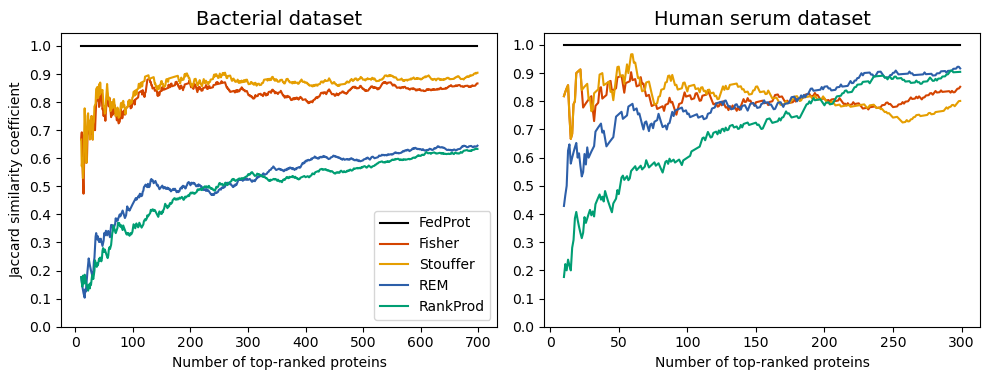

In [ ]:
min_n_genes = 10
step = 1

data, plot_two = fp_eval.plot_stats_for_topN(
    log_dfs,
    datasets = list(log_dfs.keys()),
    methods=["FedProt", "Fisher","Stouffer","REM", "RankProd"],
    metrics=["Jaccard"],
    min_n_genes=min_n_genes,
    max_n_genes=[700, 300],
    figsize=(10,3.9),
    step=step,
    color_dict=color_dict,
    sharey=False,
    )